In [1]:
from datasets import Image as Image_ds # change name because of similar PIL module
from datasets import Dataset
import pandas as pd
import numpy as np
from PIL import Image
import datasets
import io

/work/art-multimodal-benchmark/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ds = datasets.load_dataset('MKipke/benchmarking-wikidata', split='train')

In [ ]:
ds_subset = ds.select(list(range(20)))

In [ ]:
import io
def wrap_images(example):
    return {"image": Image.open(io.BytesIO(example['image'])).convert("RGB")}

ds_wrapped = ds_subset.map(wrap_images)
#ds = ds.cast_column("images", Image_ds(decode=True))
type(ds_wrapped[0]["image"])

In [ ]:
ds_wrapped[0]['image']

In [ ]:
import io 

# 1. wrap bytes (if your column is raw JPEG bytes)
ds = ds.map(lambda x: {"images": {"bytes": x["image"]}})

# 2. cast to Image → PIL decoded lazily
ds = ds.cast_column("images", Image_ds(decode=True))

In [ ]:
# 2. cast to Image → PIL decoded lazily
ds = ds.cast_column("images", Image_ds(decode=True))

In [ ]:
ds[0]['images']

In [ ]:
import os
ds.save_to_disk(os.path.join('..', 'data', 'wikidata'))

In [1]:
import torch 
emb = torch.load('../data/wikidata_embeddings/dinov2-base/dinov2-base_all_splits.pt')

In [2]:
emb.shape

torch.Size([20, 768])

In [3]:
import os
ds = datasets.load_from_disk(os.path.join('..', 'data', 'wikidata'))

In [4]:
ds = ds.class_encode_column("artist")

Casting to class labels: 100%|██████████| 6195/6195 [01:47<00:00, 57.58 examples/s]


In [5]:
ds.features['artist']

ClassLabel(names=['Alfred Sisley', 'Berthe Morisot', 'Camille Pissarro', 'Claude Monet', 'Eugène Louis Boudin', 'Georges Seurat', 'Gustave Courbet', 'Gustave Loiseau', 'Henri-Jean Guillaume Martin', 'Isaac Levitan', 'Mary Cassatt', 'Maurice Prendergast', 'Nikolay Bogdanov-Belsky', 'Paul Cézanne', 'Pierre-Auguste Renoir', 'Pyotr Konchalovsky', 'Q82445', 'Édouard Manet'])

In [27]:
from datasets import ClassLabel

# get existing feature
old_feature = ds.features["artist"]

# copy names
names = old_feature.names.copy()

# replace the label
names = [
    "Henri de Toulouse-Lautrec" if n == "Q82445" else n
    for n in names
]

# create new feature
new_feature = ClassLabel(names=names)

# cast column to updated feature
ds = ds.cast_column("artist", new_feature)

Casting the dataset:   0%|          | 0/6195 [00:00<?, ? examples/s]

Casting the dataset: 100%|██████████| 6195/6195 [00:14<00:00, 420.89 examples/s]


In [28]:
ds.features['artist']

ClassLabel(names=['Alfred Sisley', 'Berthe Morisot', 'Camille Pissarro', 'Claude Monet', 'Eugène Louis Boudin', 'Georges Seurat', 'Gustave Courbet', 'Gustave Loiseau', 'Henri-Jean Guillaume Martin', 'Isaac Levitan', 'Mary Cassatt', 'Maurice Prendergast', 'Nikolay Bogdanov-Belsky', 'Paul Cézanne', 'Pierre-Auguste Renoir', 'Pyotr Konchalovsky', 'Henri de Toulouse-Lautrec', 'Édouard Manet'])

In [32]:
# remove the unwanted column
ds = ds.remove_columns("image")

# rename the correct one
ds = ds.rename_column("images", "image")

In [33]:
ds.features

{'qid': Value('string'),
 'title': Value('string'),
 'image_url_raw': Value('string'),
 'image_filename': Value('string'),
 'inception': Value('string'),
 'collection': Value('string'),
 'collection_qid': Value('string'),
 'location': Value('string'),
 'location_qid': Value('string'),
 'material': Value('string'),
 'genre': Value('string'),
 'height_cm': Value('float64'),
 'width_cm': Value('float64'),
 'depicts': Value('string'),
 'inventory_number': Value('string'),
 'wikidata_url': Value('string'),
 'artist': ClassLabel(names=['Alfred Sisley', 'Berthe Morisot', 'Camille Pissarro', 'Claude Monet', 'Eugène Louis Boudin', 'Georges Seurat', 'Gustave Courbet', 'Gustave Loiseau', 'Henri-Jean Guillaume Martin', 'Isaac Levitan', 'Mary Cassatt', 'Maurice Prendergast', 'Nikolay Bogdanov-Belsky', 'Paul Cézanne', 'Pierre-Auguste Renoir', 'Pyotr Konchalovsky', 'Henri de Toulouse-Lautrec', 'Édouard Manet']),
 'image': Image(mode=None, decode=True)}

In [45]:
ds['artist'].features

ClassLabel(names=['Alfred Sisley', 'Berthe Morisot', 'Camille Pissarro', 'Claude Monet', 'Eugène Louis Boudin', 'Georges Seurat', 'Gustave Courbet', 'Gustave Loiseau', 'Henri-Jean Guillaume Martin', 'Isaac Levitan', 'Mary Cassatt', 'Maurice Prendergast', 'Nikolay Bogdanov-Belsky', 'Paul Cézanne', 'Pierre-Auguste Renoir', 'Pyotr Konchalovsky', 'Henri de Toulouse-Lautrec', 'Édouard Manet'])

In [34]:
ds.save_to_disk(os.path.join('..', 'data', 'wikidata_remapped'))

Saving the dataset (12/12 shards): 100%|██████████| 6195/6195 [00:21<00:00, 291.10 examples/s]


In [35]:
from collections import Counter

Counter(ds['artist'])

Counter({3: 1125,
         14: 1042,
         0: 788,
         2: 731,
         13: 671,
         4: 576,
         17: 335,
         16: 203,
         1: 153,
         5: 135,
         10: 109,
         8: 99,
         11: 82,
         9: 62,
         7: 47,
         12: 31,
         15: 5,
         6: 1})

In [82]:
def plot_distribution(ds, title, top_k=20):

    artist_counts = Counter(ds['artist'])
    items = artist_counts.most_common(top_k)
    labels, values = zip(*items)

    artist_names = []
    for label in labels:
        label_name = ds.features["artist"].int2str(label)
        artist_names.append(label_name)

    plt.figure(figsize=(10,6))
    bars = plt.barh(artist_names, values)

    # Add count labels to each bar
    for bar, value in zip(bars, values):
        plt.text(
            bar.get_width() + 0.5,  # slightly offset to the right of the bar
            bar.get_y() + bar.get_height() / 2,  # vertically center
            str(value),
            va='center'
        )

    plt.xticks(rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

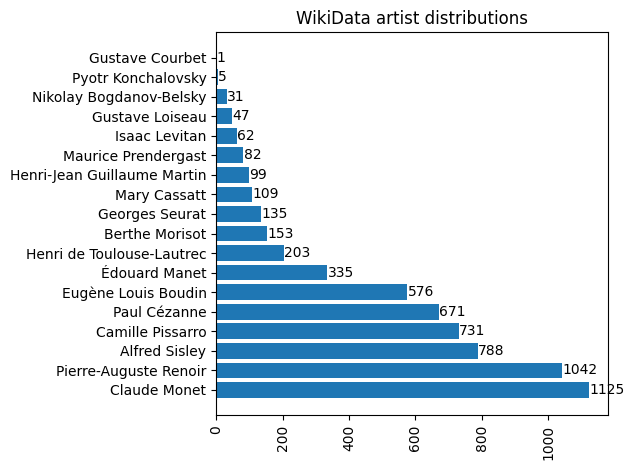

In [60]:
plot_distribution(ds, 'WikiData artist distributions', top_k=20)

In [51]:
wikiart = datasets.load_from_disk(os.path.join('..', 'data', 'wikiart_filtered_remapped_FINAL'))

In [52]:
def remap_features(ds_original, ds_filtered, label):

    original_feature = ds_original.features[label] # the ClassLabel feature
    original_names = original_feature.names

    # classes(names) in new subclassification dataset:
    used_class_names = sorted(list(set(ds_filtered[f"{label}_str"])))
    new_class_label = ClassLabel(names=used_class_names)

    # set up function to remap from str -> int for new ClassLabels
    def remap_labels(example):
        example[label] = new_class_label.str2int(example[f"{label}_str"])
        return example
    
    # use map to remap classlabels
    ds_filtered = ds_filtered.map(remap_labels)

    # recast the class label feature to new labels
    new_features = ds_filtered.features.copy()
    new_features[label] = new_class_label
    ds_filtered = ds_filtered.cast(new_features)

    return ds_filtered

def filter_data(ds, label, subclassification_task):
    ds = ds.add_column('old_indices', range(len(ds)))

    # find the rows that matches the subclassification task
    subclass_indices = [idx for idx, a in enumerate(ds[f'{label}_str']) if a in subclassification_task]
    ds_subset = ds.select(subclass_indices)

    # remap labels to fit to new number of classes for subclassification task
    ds_subset = remap_features(ds, ds_subset, label)


        #ds_split = ds_subset.train_test_split(test_size=0.2, seed=seed, stratify_by_column=label)

        #ds_splits = {
         #   'train': ds_split['train'], # train/val set
          #  'test': ds_split['test'] # hold-out test set - we're not touching this until the end
          #  }
    return ds_subset

In [62]:
Counter(wikiart['artist_str'])

Counter({'vincent-van-gogh': 1606,
         'nicholas-roerich': 1272,
         'pierre-auguste-renoir': 1228,
         'claude-monet': 1110,
         'camille-pissarro': 864,
         'pyotr-konchalovsky': 766,
         'gustave-dore': 743,
         'john-singer-sargent': 700,
         'albrecht-durer': 667,
         'marc-chagall': 651,
         'rembrandt': 642,
         'pablo-picasso': 597,
         'edgar-degas': 542,
         'paul-cezanne': 509,
         'ivan-shishkin': 500,
         'boris-kustodiev': 490,
         'childe-hassam': 485,
         'alfred-sisley': 463,
         'ilya-repin': 457,
         'martiros-saryan': 451,
         'camille-corot': 434,
         'henri-matisse': 403,
         'isaac-levitan': 388,
         'salvador-dali': 387,
         'paul-gauguin': 352,
         'maurice-prendergast': 347,
         'eugene-boudin': 346,
         'amedeo-modigliani': 331,
         'ernst-ludwig-kirchner': 329,
         'william-merritt-chase': 326,
         'zinaida-ser

In [ ]:
artists_wikiart = [
    "camille-pissarro",
    "paul-cezanne",
    "pierre-auguste-renoir",
    "alfred-sisley",
    "mary-cassatt",
    #"gustave-loiseau",
    "edouard-cortes",
    "berthe-morisot",
    "georges-seurat",
    #"henri-martin",
    #"maurice-prendergast",
    #"isaac-levitan",
    "edouard-manet",
   #"nikolay-bogdanov-belsky",
    "henri-de-toulouse-lautrec",
    "claude-monet",
    "eugene-boudin",
    #"pyotr-konchalovsky"
]

In [63]:
ds['artist'].features

ClassLabel(names=['Alfred Sisley', 'Berthe Morisot', 'Camille Pissarro', 'Claude Monet', 'Eugène Louis Boudin', 'Georges Seurat', 'Gustave Courbet', 'Gustave Loiseau', 'Henri-Jean Guillaume Martin', 'Isaac Levitan', 'Mary Cassatt', 'Maurice Prendergast', 'Nikolay Bogdanov-Belsky', 'Paul Cézanne', 'Pierre-Auguste Renoir', 'Pyotr Konchalovsky', 'Henri de Toulouse-Lautrec', 'Édouard Manet'])

In [68]:
artists_wikidata = [
    'Alfred Sisley', 
    'Berthe Morisot', 
    'Camille Pissarro', 
    'Claude Monet', 
    'Eugène Louis Boudin', 
    'Georges Seurat', 
    #'Gustave Courbet', 
    #'Gustave Loiseau', 
    #'Henri-Jean Guillaume Martin', 
    #'Isaac Levitan', 
    'Mary Cassatt', 
    #'Maurice Prendergast', 
    #'Nikolay Bogdanov-Belsky', 
    'Paul Cézanne', 
    'Pierre-Auguste Renoir', 
    #'Pyotr Konchalovsky', 
    'Henri de Toulouse-Lautrec', 
    'Édouard Manet'
]

In [65]:
artists_wikiart = [
    "camille-pissarro",
    "paul-cezanne",
    "pierre-auguste-renoir",
    "alfred-sisley",
    "mary-cassatt",
    #"gustave-loiseau",
    #"edouard-cortes",
    "berthe-morisot",
    "georges-seurat",
    #"henri-martin",
    #"maurice-prendergast",
    #"isaac-levitan",
    "edouard-manet",
   #"nikolay-bogdanov-belsky",
    "henri-de-toulouse-lautrec",
    "claude-monet",
    "eugene-boudin",
    #"pyotr-konchalovsky"
]

In [71]:
len(artists_wikiart) == len((artists_wikidata))

True

In [70]:
len((artists_wikidata))

11

In [ ]:
ds_impr_subset = filter_data(wikiart, 'artist', artists)

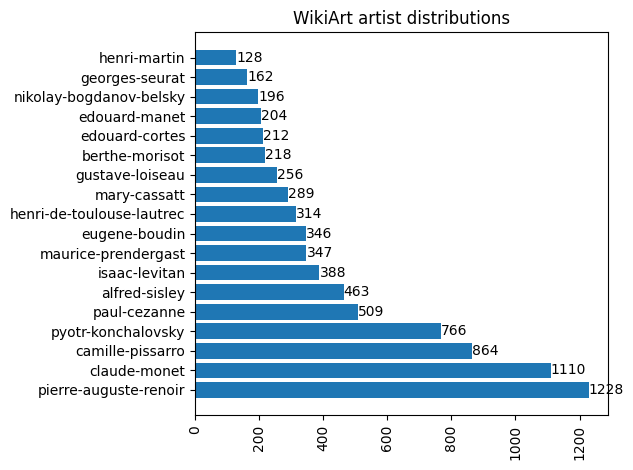

In [61]:
plot_distribution(ds_impr_subset, 'WikiArt artist distributions', top_k=20)

In [38]:
len(ds)

6195

In [43]:
problems = [8, 11, 9, 7, 12, 15, 6]

In [44]:
for integer in problems:
    label_id = ds.features["artist"].int2str(integer)
    print(label_id)

Henri-Jean Guillaume Martin
Maurice Prendergast
Isaac Levitan
Gustave Loiseau
Nikolay Bogdanov-Belsky
Pyotr Konchalovsky
Gustave Courbet


In [37]:
label_id

'Gustave Courbet'

In [31]:
ds.features

{'qid': Value('string'),
 'title': Value('string'),
 'image_url_raw': Value('string'),
 'image_filename': Value('string'),
 'inception': Value('string'),
 'collection': Value('string'),
 'collection_qid': Value('string'),
 'location': Value('string'),
 'location_qid': Value('string'),
 'material': Value('string'),
 'genre': Value('string'),
 'height_cm': Value('float64'),
 'width_cm': Value('float64'),
 'depicts': Value('string'),
 'inventory_number': Value('string'),
 'wikidata_url': Value('string'),
 'artist': ClassLabel(names=['Alfred Sisley', 'Berthe Morisot', 'Camille Pissarro', 'Claude Monet', 'Eugène Louis Boudin', 'Georges Seurat', 'Gustave Courbet', 'Gustave Loiseau', 'Henri-Jean Guillaume Martin', 'Isaac Levitan', 'Mary Cassatt', 'Maurice Prendergast', 'Nikolay Bogdanov-Belsky', 'Paul Cézanne', 'Pierre-Auguste Renoir', 'Pyotr Konchalovsky', 'Henri de Toulouse-Lautrec', 'Édouard Manet']),
 'image': Value('binary'),
 'images': Image(mode=None, decode=True)}

In [8]:
import numpy as np

label_id = ds.features["artist"].str2int("Q82445")

indices = np.where(np.array(ds["artist"]) == label_id)[0]
subset = ds.select(indices)

In [15]:
subset['qid']

Column(['Q27954931', 'Q131584729', 'Q64491271', 'Q29916008', 'Q30063927'])

In [40]:
import matplotlib.pyplot as plt 
import random
import math

def plot_examples(ds, label_col, example_class, num_examples):

    indices = [i for i, l in enumerate(ds[label_col]) if l == example_class]

    if len(indices) == 0:
        print(f"No examples found for class '{example_class}'")
        return

    # randomly select indices
    selected_indices = random.sample(indices, min(num_examples, len(indices)))

    # determine grid size
    cols = min(5, len(selected_indices))  # max 5 images per row
    rows = math.ceil(len(selected_indices) / cols)

    # plot the images
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, idx in enumerate(selected_indices):
        img = ds[idx]['image']  # assumes column is called 'image' and stores PIL.Image
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')

    plt.suptitle(f"{example_class}")
    plt.tight_layout()
    plt.show()

In [25]:
label_id = ds.features["artist"].str2int("Q82445")

In [ ]:
ds[0][]

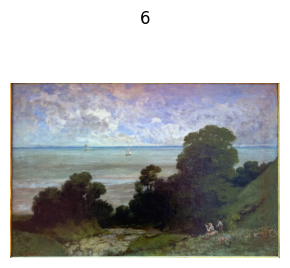

In [41]:
plot_examples(ds, 'artist', 6, 20)

In [75]:
wikiart_impr_subset = filter_data(wikiart, 'artist', artists_wikiart)

def map_int_to_str(example):
    return {
        'artist_str': ds.features['artist'].int2str(example['artist'])
    }

ds = ds.map(map_int_to_str, batched=False)
wikidata_impr_subset = filter_data(ds, 'artist', artists_wikidata)

Casting the dataset: 100%|██████████| 5868/5868 [00:07<00:00, 735.56 examples/s]


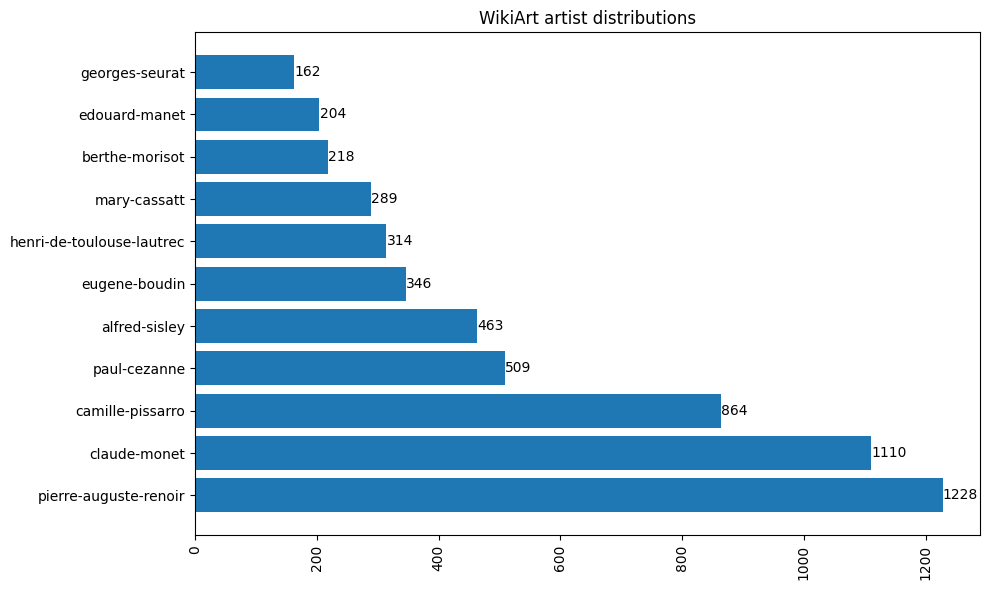

In [83]:
plot_distribution(wikiart_impr_subset, 'WikiArt artist distributions', top_k=20)

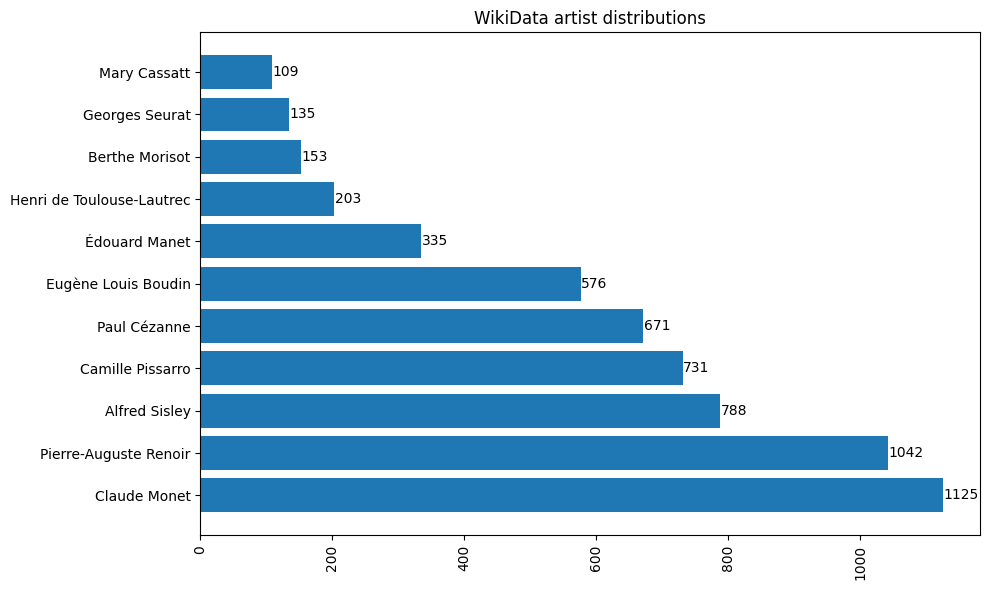

In [84]:
plot_distribution(wikidata_impr_subset, 'WikiData artist distributions', top_k=20)